## Initialisation

In [3]:
%pip install pyspark pandas matplotlib seaborn

     ---------------------------------------- 0.0/455.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/455.4 MB ? eta -:--:--
     ---------------------------------------- 0.3/455.4 MB 2.9 MB/s eta 0:02:35
     ---------------------------------------- 0.7/455.4 MB 5.9 MB/s eta 0:01:18
     ---------------------------------------- 1.3/455.4 MB 7.4 MB/s eta 0:01:02
     ---------------------------------------- 1.9/455.4 MB 8.4 MB/s eta 0:00:54
     ---------------------------------------- 2.4/455.4 MB 9.1 MB/s eta 0:00:50
     ---------------------------------------- 3.0/455.4 MB 9.6 MB/s eta 0:00:48
     ---------------------------------------- 3.5/455.4 MB 9.6 MB/s eta 0:00:48
     ---------------------------------------- 3.9/455.4 MB 9.7 MB/s eta 0:00:47
     --------------------------------------- 4.4/455.4 MB 10.0 MB/s eta 0:00:46
     --------------------------------------- 4.9/455.4 MB 10.1 MB/s eta 0:00:45
     --------------------------------------- 5.3/455.4


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
# Cette cellule ne sert que si le nom du PC a des caractères non autorisés par Spark pour construire l'URL interne
# Elle ne sert qu'à contourner le problème en développement pour avoir un host local 

import os

os.environ["SPARK_LOCAL_HOSTNAME"] = "localhost"

from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("WorldCupAnalysis")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .getOrCreate()
)

print(spark.version)

4.1.2


In [46]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

spark = SparkSession.builder \
    .appName("WorldCupAnalysis") \
    .getOrCreate()

## Importation

In [47]:
root_folder = "data"

teams = spark.read.csv(root_folder + "/wc_2026_teams.csv", header=True, inferSchema=True)
fixtures = spark.read.csv(root_folder + "/wc_2026_fixtures.csv", header=True, inferSchema=True)
editions = spark.read.csv(root_folder + "/wc_all_editions.csv", header=True, inferSchema=True)
matches = spark.read.csv(root_folder + "/wc_all_matches.csv", header=True, inferSchema=True)
scorers = spark.read.csv(root_folder + "/wc_top_scorers.csv", header=True, inferSchema=True)

In [48]:
for df_name, df in {
    "teams": teams,
    "fixtures": fixtures,
    "editions": editions,
    "matches": matches,
    "scorers": scorers
}.items():
    print(f"\n=== {df_name} ===")
    df.printSchema()
    df.show(5)


=== teams ===
root
 |-- team: string (nullable = true)
 |-- group: string (nullable = true)
 |-- confederation: string (nullable = true)
 |-- fifa_rank: integer (nullable = true)
 |-- coach: string (nullable = true)
 |-- best_wc_result: string (nullable = true)
 |-- debut_2026: string (nullable = true)

+------------+-----+-------------+---------+--------------+--------------------+----------+
|        team|group|confederation|fifa_rank|         coach|      best_wc_result|debut_2026|
+------------+-----+-------------+---------+--------------+--------------------+----------+
|      Mexico|    A|     CONCACAF|       15|Javier Aguirre|Quarter-finals (1...|        No|
|South Africa|    A|          CAF|       60|    Hugo Broos|Group stage (1998...|        No|
| South Korea|    A|          AFC|       25| Hong Myung-bo|  Semi-finals (2002)|        No|
|     Czechia|    A|         UEFA|       41|    Ivan Hasek|Runner-up (1934,1...|        No|
|      Canada|    B|     CONCACAF|       30|  Jess

## Evolution du nombres d'équipes participantes

+----+-----+
|year|teams|
+----+-----+
|1930|   13|
|1934|   16|
|1938|   15|
|1950|   13|
|1954|   16|
|1958|   16|
|1962|   16|
|1966|   16|
|1970|   16|
|1974|   16|
|1978|   16|
|1982|   24|
|1986|   24|
|1990|   24|
|1994|   24|
|1998|   32|
|2002|   32|
|2006|   32|
|2010|   32|
|2014|   32|
+----+-----+
only showing top 20 rows


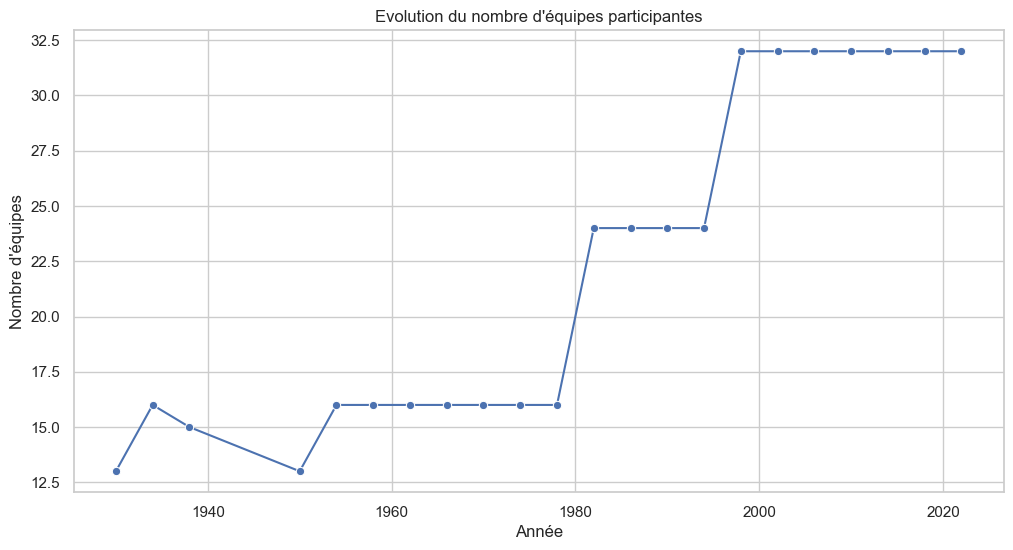

In [ ]:
editions.select("year", "teams").show()

pdf = pd.DataFrame(
    editions.select("year", "teams").collect(),
    columns=["year", "teams"]
)

plt.figure(figsize=(12,6))
sns.lineplot(data=pdf, x="year", y="teams", marker="o")

plt.title("Evolution du nombre d'équipes participantes")
plt.xlabel("Année")
plt.ylabel("Nombre d'équipes")
plt.show()

## Pays les plus titrés

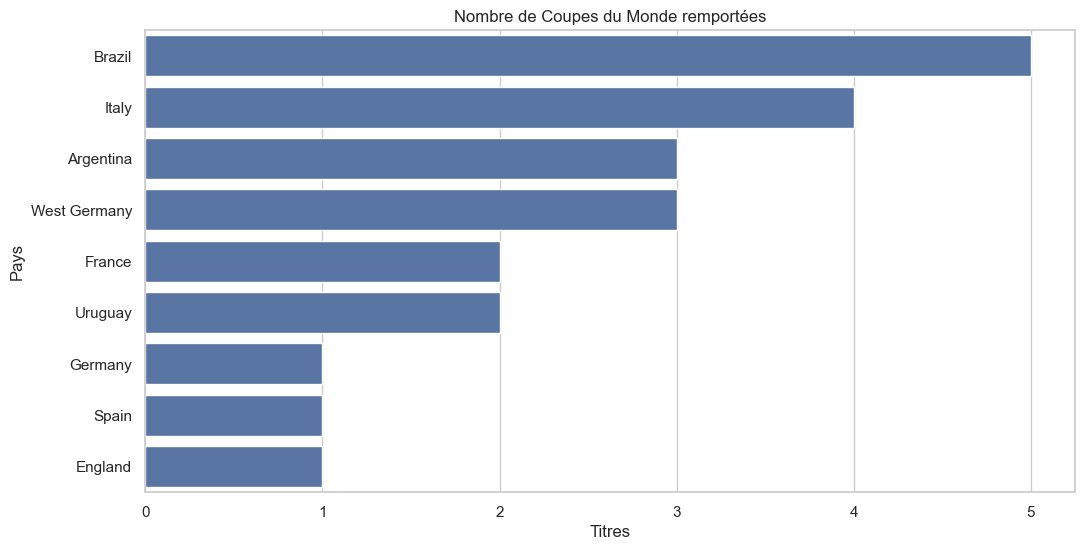

In [32]:
titles = editions.groupBy("champion") \
    .count() \
    .orderBy(desc("count"))

pdf = pd.DataFrame(
    [row.asDict() for row in titles.collect()]
)

plt.figure(figsize=(12,6))
sns.barplot(data=pdf,
            x="count",
            y="champion")

plt.title("Nombre de Coupes du Monde remportées")
plt.xlabel("Titres")
plt.ylabel("Pays")
plt.show()

## Répartition des titres par continent

In [72]:
mapping_data = [
    ("UEFA", "Europe"),
    ("CONMEBOL", "South America"),
    ("CAF", "Africa"),
    ("AFC", "Asia"),
    ("CONCACAF", "North America"),
    ("OFC", "Oceania")
]

# Création d'un dictionnaire Python
mapping_dict = dict(mapping_data)

# Expression de mapping
mapping_expr = F.create_map(
    *[F.lit(x) for pair in mapping_dict.items() for x in pair]
)

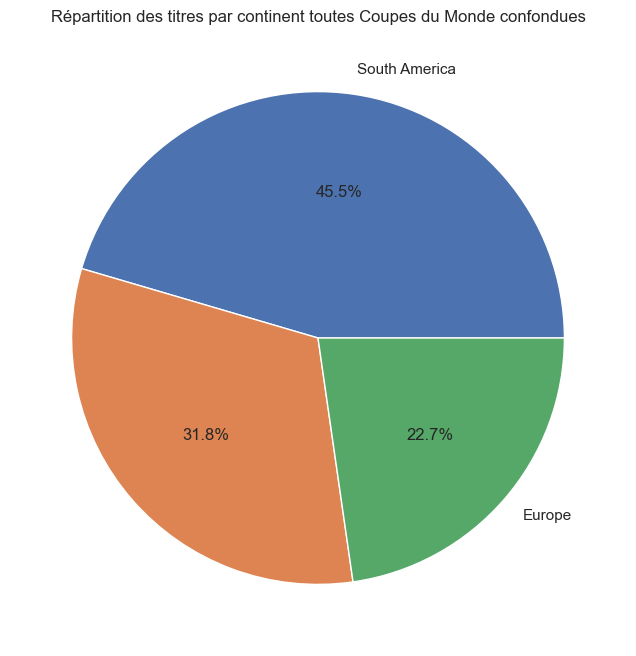

In [136]:
champions = (editions.join(
        teams,
        editions.champion == teams.team,
        "left"
    )
    .withColumn(
        "continent",
        mapping_expr[F.col("confederation")]
    )
)

continent_titles = (
    champions.groupBy("continent")
    .count()
    .orderBy(desc("count"))
)

pdf = pd.DataFrame(
    [row.asDict() for row in continent_titles.collect()]
)
plt.figure(figsize=(8, 8))
plt.pie(
    pdf["count"],
    labels=pdf["continent"],
    autopct="%1.1f%%"
)

plt.title("Répartition des titres par continent toutes Coupes du Monde confondues")
plt.show()

In [135]:
champions = (editions.join(
        teams,
        editions.champion == teams.team,
        "left"
    )
)

(champions.select("champion")
        .filter(champions
        .confederation.isNull())
        .distinct()
        .orderBy("champion")
        .show()
)


+------------+
|    champion|
+------------+
|       Italy|
|West Germany|
+------------+



## Top 10 des meilleurs buteurs de l'histoire en Coupe du Monde

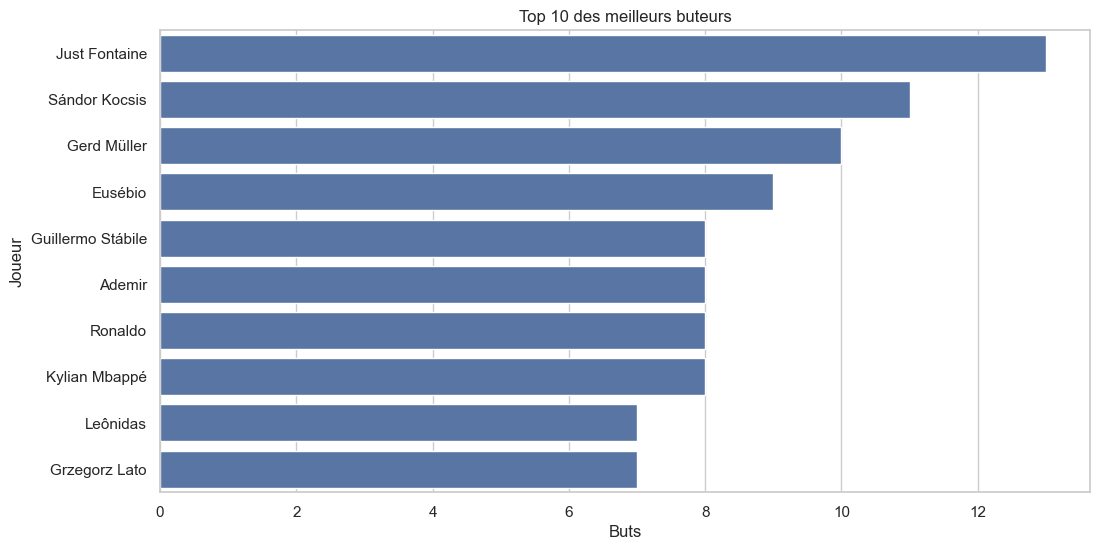

In [58]:
top10 = scorers.orderBy(desc("goals")).limit(10)

pdf = pd.DataFrame(
    [row.asDict() for row in top10.collect()]
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=pdf,
    x="goals",
    y="player"
)

plt.title("Top 10 des meilleurs buteurs")
plt.xlabel("Buts")
plt.ylabel("Joueur")
plt.show()